## Gamma Ray Burst (GRB) Clustering
GRBs are extremely energetic astronomical events that manifest themselves as powerful gamma rays burst. The duration of this energetic event, that can last from milliseconds to hours, can tell us more about the astrophysical nature of the emission.
We can classify them in two main classes:
- Long Gamma Ray Burst, lasts longer than 3 seconds
- Short Gmma Ray Burst, shorter than 3 seconds

Using clustering techniques, such as KMeans and Mean shift clustering, we want to classify the type of GRB from the duration of the event measured.

In [1]:
from dynesty import utils as dyfunc
import numpy as np
from matplotlib import pyplot as plt
path = 'C:/Users/alexv/Desktop/Università/astrostat/astrostatistics_bicocca_2025/solutions/transient.npy'
from sklearn.mixture import GaussianMixture
from astroML.resample import jackknife
from astroML.stats import sigmaG
from scipy.stats import chi2
import scipy
import scipy.stats as stats
#from astroML.plotting import setup_text_plots
#setup_text_plots(fontsize = 10, usetex = True)
from scipy.stats import loguniform
from sklearn.neighbors import KernelDensity

def kde_sklearn(data, bandwidth = 1.0):
    kde_skl = KernelDensity(bandwidth = bandwidth)
    kde_skl.fit(data[:, np.newaxis])
    log_pdf = kde_skl.score_samples(xgrid[:, np.newaxis]) # sklearn returns log(density)
    return np.exp(log_pdf)


In [2]:
import requests

# Download file
r = requests.get('https://user-web.icecube.wisc.edu/~grbweb_public/Summary_table.txt')
with open("Summary_table.txt", 'wb') as f:
    f.write(r.content)


# Read headers
with open("Summary_table.txt",'r') as f:
    names = np.array([n.strip().replace(" ","_") for n in f.readlines()[1].replace("#","").replace("\n","").lstrip().split('    ') if n.strip()!=''])
print(names)
# Read content
data = np.loadtxt("Summary_table.txt", dtype='str',unpack='True')
grb = dict(zip(names, data))
for i in ['T90', "redshift", "T90_error"]:
          grb[i] = np.array(grb[i], dtype ='float')

['GRB_name' 'GRB_name_Fermi' 'T0' 'ra' 'decl' 'pos_error' 'T90'
 'T90_error' 'T90_start' 'fluence' 'fluence_error' 'redshift' "'T100'"
 'GBM_located' 'mjd_(T0)']


C:\Users\alexv\AppData\Local\Temp\ipykernel_3116\2581583988.py:14: UserWarning: Input line 1 contained no data and will not be counted towards `max_rows=50000`.  This differs from the behaviour in NumPy <=1.22 which counted lines rather than rows.  If desired, the previous behaviour can be achieved by using `itertools.islice`.
Please see the 1.23 release notes for an example on how to do this.  If you wish to ignore this warning, use `warnings.filterwarnings`.  This warning is expected to be removed in the future and is given only once per `loadtxt` call.
  data = np.loadtxt("Summary_table.txt", dtype='str',unpack='True')


(15, 8781)
(7522,), (7522,)


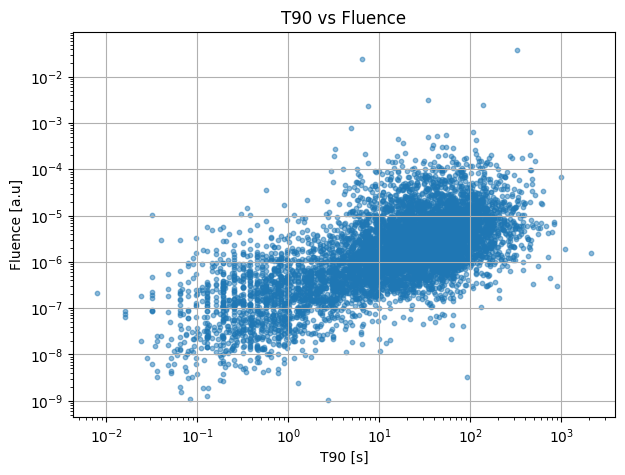

[1.0450e-06 1.2475e-07 7.9799e-07 ... 2.4858e-08 1.6510e-07 2.6055e-06]


In [11]:
print(data.shape)
t90 = grb['T90']
t90_err = grb['T90_error']
z = grb['redshift']
fluence = data[9, :]
t90 = np.array(t90, dtype=float)
fluence = np.array(fluence, dtype=float)
fluence = fluence[t90>-999]
t90 = t90[t90>-999]
z = np.array(z, dtype = float)

t90 = t90[fluence>0]
fluence = fluence[fluence>0]
print(f'{t90.shape}, {fluence.shape}')
plt.figure(figsize=(7,5))
plt.scatter(t90, fluence, alpha=0.5, s=10)
plt.xlabel('T90 [s]')
plt.ylabel('Fluence [a.u]')
plt.yscale('log')
plt.xscale('log')
plt.title('T90 vs Fluence')
plt.grid(True)
plt.show()
print(fluence)


[0.01       0.03538462 0.06076923 0.08615385 0.11153846 0.13692308
 0.16230769 0.18769231 0.21307692 0.23846154 0.26384615 0.28923077
 0.31461538 0.34       0.36538462 0.39076923 0.41615385 0.44153846
 0.46692308 0.49230769 0.51769231 0.54307692 0.56846154 0.59384615
 0.61923077 0.64461538 0.67       0.69538462 0.72076923 0.74615385
 0.77153846 0.79692308 0.82230769 0.84769231 0.87307692 0.89846154
 0.92384615 0.94923077 0.97461538 1.        ]
0.11153846153846153


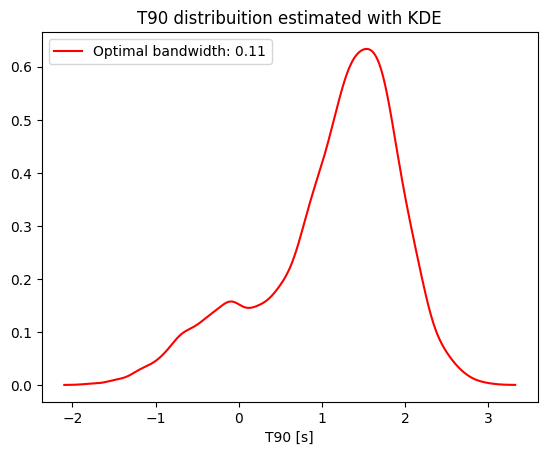

In [93]:
#Density estimation of the T90 distribuition with KD
from sklearn.model_selection import GridSearchCV
#cleaning data
t90 = np.log10(t90)
t90 = t90.astype(float)
fluence = fluence[fluence>0]
z = z[z>-999]
mask = np.isfinite(t90) & ~np.isnan(t90)
t90_clean = t90[mask]

bwrange = np.linspace(0.01,1.0, 40) # Test 40 bandwidths from 0.1 to 1.0
print(bwrange)
K = 5 #  5-fold cross validation
grid = GridSearchCV(KernelDensity(), {'bandwidth': bwrange}, cv= K) 
grid.fit(t90_clean[:, None])
h_opt = grid.best_params_['bandwidth']
print(h_opt)
xgrid = np.linspace(t90_clean.min(), t90_clean.max(), 1000)
pdf = kde_sklearn(t90_clean,bandwidth=h_opt)
plt.plot(xgrid,pdf,c='red', label = f'Optimal bandwidth: {h_opt:.2f}')
plt.title("T90 distribuition estimated with KDE")
plt.xlabel("T90 [s]")
plt.legend()
plt.show()

Already by looking at the pdf of T90, two modes can be identified.
Let's see if fluence or redshift show this bimodality:

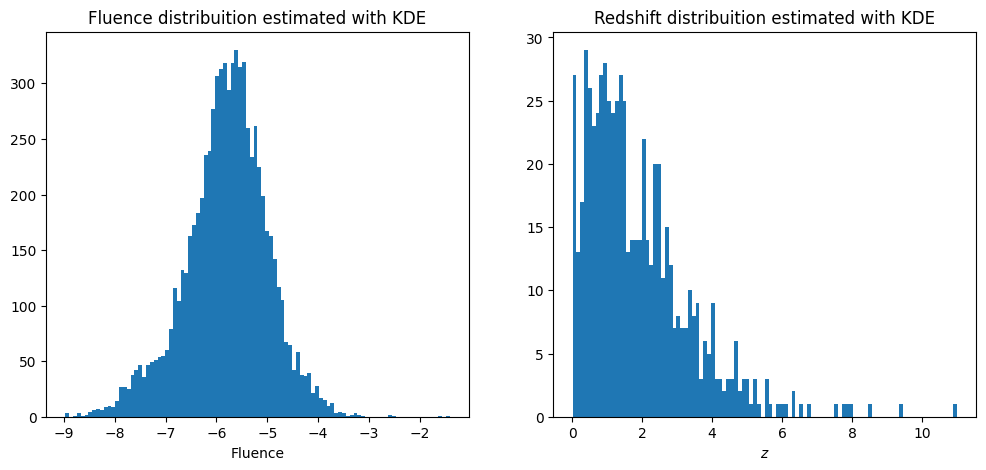

In [117]:

#Plots
plt.figure(figsize=(12, 5))
f_log = np.log10(fluence)
f_log = f_log.astype(float)

mask_f = np.isfinite(f_log) & ~np.isnan(f_log)
f_log = f_log[mask_f]
plt.subplot(1, 2, 1)
plt.hist(f_log, bins = 100)
plt.title("Fluence distribuition estimated with KDE")
plt.xlabel("Fluence")

plt.subplot(1,2,2)
plt.hist(z, bins = 100)
plt.title("Redshift distribuition estimated with KDE")
plt.xlabel(r"$z$")

plt.show()

The fluence and redshift distribuition are not very informative about the searched bimodality

### K Means Clustering

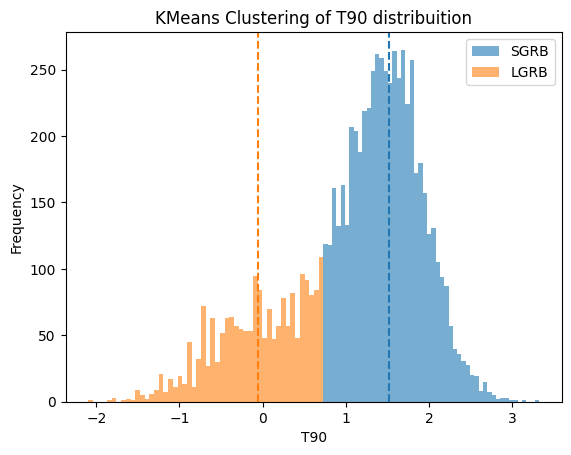

In [95]:
#Clustering analysis with KMeans
from sklearn.metrics import confusion_matrix
from sklearn.cluster import KMeans
from sklearn import preprocessing

# Reshape for KMeans
t90_res = t90_clean[:, np.newaxis]
clf = KMeans(n_clusters=2,n_init='auto') 
clf.fit(t90_res)
centers = clf.cluster_centers_ #location of the clusters
labels = clf.predict(t90_res) #labels for each of the points

plt.hist(t90_res[labels == 0], bins=50, alpha=0.6, label='SGRB', color='C0')
plt.hist(t90_res[labels == 1], bins=50, alpha=0.6, label='LGRB', color='C1')

plt.axvline(centers[0], color='C0', linestyle='--')
plt.axvline(centers[1], color='C1', linestyle='--')
plt.xlabel("T90")

plt.ylabel("Frequency")
plt.legend()
plt.title("KMeans Clustering of T90 distribuition")
plt.show()





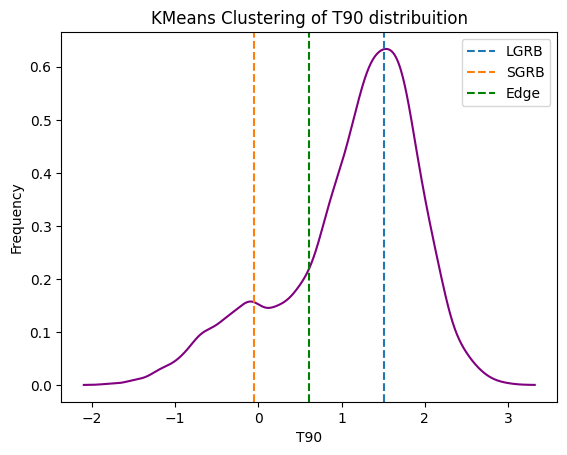

[[ 1.51413372]
 [-0.05474168]]
[0 1 0 ... 1 0 1]


In [96]:
group0 = t90_res[clf.labels_ == 0]
group1 = t90_res[clf.labels_ == 1]
edge_log = np.mean([group0.max(), group1.min()])


plt.plot(xgrid, pdf, color = 'purple')

plt.axvline(centers[0], color='C0', linestyle='--', label = 'LGRB')
plt.axvline(centers[1], color='C1', linestyle='--', label = 'SGRB')
plt.xlabel("T90")
plt.axvline(edge_log, color = 'green', linestyle = '--', label = 'Edge')
plt.ylabel("Frequency")
plt.legend()
plt.title("KMeans Clustering of T90 distribuition")
plt.show()

print(centers)
print(labels)



In [119]:
centers_new = 10**(centers)
edge = 10 ** edge_log
print("Location of the clusters:", centers_new)
print("Location of the threshold:", edge)


Location of the clusters: [[32.66884046]
 [ 0.88157308]]
Location of the threshold: 4.09878030638384


### Mean Shift Clustering

[-1  0  1]
0.5441535655292203
[[1.48725666]
 [0.00191821]]
4.09878030638384


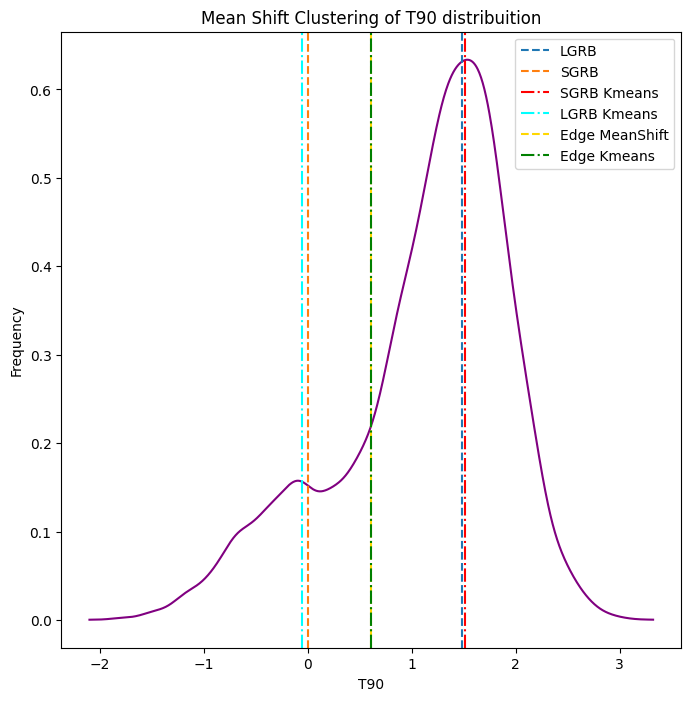

In [122]:
from sklearn.cluster import MeanShift
from sklearn.decomposition import PCA
from sklearn.cluster import estimate_bandwidth

#Normalize data to unit variance and zero mean
scaler = preprocessing.StandardScaler()

X_scaled = scaler.fit_transform(t90_res)
bandwidth = estimate_bandwidth(X_scaled, quantile=0.25)


ms = MeanShift(bandwidth=bandwidth, 
               bin_seeding=True, 
               cluster_all=False)

ms.fit(X_scaled)
labels_unique = np.unique(ms.labels_)
#in order to account once for each label, and negative label refers to outliers or unassigned points
labels_ms = ms.predict(t90_res)
print(labels_unique)
print(bandwidth)

group0 = t90_res[labels_ms == 0]
group1 = t90_res[labels_ms == 1]
edge_log = np.mean([group0.max(), group1.min()])

edge_ms = 10**edge_log

# Plots
fig = plt.figure(figsize=(8, 8))
ax = fig.add_subplot()
cluster_centers = scaler.inverse_transform(ms.cluster_centers_)
print(cluster_centers)
print(edge_ms)
ax.plot(xgrid, pdf, color = 'purple')

plt.axvline(cluster_centers[0,0], color='C0', linestyle='--', label = 'LGRB')
plt.axvline(cluster_centers[1,0], color='C1', linestyle='--', label = 'SGRB')
plt.axvline(centers[0], color = 'red', linestyle = '-.', label = 'SGRB Kmeans')
plt.axvline(centers[1], color = 'cyan', linestyle = '-.', label = 'LGRB Kmeans')
plt.axvline(np.log10(edge_ms), color = 'gold', linestyle = '--', label = 'Edge MeanShift')
plt.axvline(np.log10(edge), color = 'green', linestyle = '-.', label = 'Edge Kmeans')
plt.xlabel("T90")
plt.ylabel("Frequency")
plt.legend()
plt.title("Mean Shift Clustering of T90 distribuition")
plt.show()



In [120]:
centers_new = 10**(cluster_centers)
print("Location of the clusters:", centers_new)
print("Edge", edge_ms)

Location of the clusters: [[30.70836271]
 [ 1.00442662]]
Edge 4.09878030638384


In [116]:
#How much the two methods agree:

print("Confusion matrix:\n", confusion_matrix(labels_ms,labels))


Confusion matrix:
 [[5708 1472]
 [   0  460]]


The two methods predict similar edges and cluster centers, but disagree on the classification of 20% of SGRBs